In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import json
from shapely.geometry import Polygon, MultiPolygon

## Microclimate sensor readings

In [14]:
base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.0/catalog/datasets/'
base_url_v2_1 = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'

#Dataset name
sensor_reading_dataset = 'microclimate-sensor-readings'
number_of_records = 100

# Add a filter for the number of results returned
filters = f'records?limit={number_of_records}&offset=0&timezone=UTC'

In [5]:
sensor_reading_url = f'{base_url_v2}{sensor_reading_dataset}/{filters}'
sensor_reading_url

'https://data.melbourne.vic.gov.au/api/explore/v2.0/catalog/datasets/microclimate-sensor-readings/records?limit=100&offset=0&timezone=UTC'

In [9]:
# Use requests to get the data
result = requests.get(sensor_reading_url)

In [10]:
result_json = result.json()

In [11]:
result_json.keys()

dict_keys(['total_count', 'links', 'records'])

In [12]:
result_json['total_count']

1340

In [13]:
records = result_json['records']

In [14]:
pm10_df = pd.json_normalize(records)
pm10_df.drop(columns = ['links'], inplace=True)

In [15]:
column_names = pm10_df.columns.values.tolist()
column_names = [i.split('.')[-1] for i in column_names]
pm10_df.columns = column_names

In [16]:
pm10_df

,id,timestamp,size,local_time,id,site_id,sensor_id,value,type,units,gatewayhub_id,site_status
0,9f9b74b79e33f6ac7eaa6a99bd13c875dc0efa6c,2023-07-27T00:21:56.081Z,80,2023-07-26T14:15:02+00:00,7595165,1014,5b,80.14,TPH.RH,%,arc1045,C
1,086f643d075f06e64b4d73af7a7ee6bc0f3242da,2023-07-27T00:21:56.081Z,80,2023-07-26T14:15:05+00:00,7595073,1011,5b,75.54,TPH.RH,%,arc1055,C
2,04bd749003363e5644a9909f4b564a14c45796eb,2023-07-27T00:21:56.081Z,89,2023-07-26T14:15:05+00:00,7595078,1011,5c,1028.80,TPH.PRESSURE,hPa,arc1055,C
3,b0f2dd975d9242c4b8188fdd77bb0c7e12123bb6,2023-07-27T00:21:56.081Z,81,2023-07-26T14:15:05+00:00,7595112,1012,5a,8.72,TPH.TEMP,C,arc1048,C
4,b6369e51c1f97a99371028d96f8f81acff8da909,2023-07-27T00:21:56.081Z,81,2023-07-26T14:15:07+00:00,7595204,1016,5a,9.35,TPH.TEMP,C,arc1049,C
...,...,...,...,...,...,...,...,...,...,...,...,...
95,68a3cb9f288e8085b5669ff55ee63217240c9ba7,2023-07-27T00:21:56.081Z,123,2023-07-26T16:00:00+00:00,7595503,1012,0b.EPA-1h.NOPK.EPA-24h,28.90,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1048,C
96,106b81f009dd10f90de8420daa50e98dbba571cf,2023-07-27T00:21:56.081Z,95,2023-07-26T16:00:00+00:00,7595518,1012,5a.EPA-1h,8.53,TPH.TEMP-EPA-1h,C,arc1048,C
97,b07ffdc323ba9a285d7d6e6705c8f9e79187c0c5,2023-07-27T00:21:56.081Z,108,2023-07-26T16:00:00+00:00,7595537,1014,0a.EPA-1h.NOPK,17.90,PM2.5-EPA-1h-NOPK,ug/m^3,arc1045,C
98,2c72c87da757dd56ceddedfa15ab2be98255bd96,2023-07-27T00:21:56.081Z,124,2023-07-26T16:00:00+00:00,7595538,1014,0a.EPA-1h.NOPK.EPA-24h,11.20,PM2.5-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1045,C


In [17]:
groupbyfields = ['site_id']
aggregatebyfields = ["count", "mean"]

# Create new DataFrame with value counts and mean values for each site.
pm10SiteCount = pd.DataFrame(pm10_df.groupby(groupbyfields, as_index=False)['value'].agg(aggregatebyfields)
                             .add_prefix('value_'))
pm10SiteCount = pm10SiteCount.reset_index()
pm10SiteCount

,site_id,value_count,value_mean
0,1009,9,18.077778
1,1011,23,205.540000
2,1012,17,18.361176
3,1014,27,99.592963
4,1016,24,145.839167


In [9]:
# Function that extracts the data from the JSON url
def get_data(base, data_url, offset = 0):
    
    filters = f'records?limit={100}&offset={offset}&timezone=UTC'
    url = f'{base}{data_url}/{filters}'
    result = requests.get(url)
    # if you need to extract more than 9900 records, enter the api key like below
    #result = requests.get(url + f'&apikey={API_KEY}')
    result_json = result.json()
    max_results = result_json['total_count']
    links = result_json['links']
    records = result_json['records']
    records_df = pd.json_normalize(records)
    
    # fix columns names
    records_df.drop(columns=['links'],inplace=True)
    column_names = records_df.columns.values.tolist()
    
    column_names = [i.split('.')[-1] for i in column_names]
    records_df.columns = column_names
    
    next_url = None
    
    # get next url
    if records_df.shape[0] != max_results:
        for l in links:
            if l['rel']=='next':
                next_url = l['href']
                
    return [records_df, next_url, column_names]

In [10]:
def add_to_dataframe(dataframe, new_data):
    df = pd.concat([dataframe, new_data])
    return df

In [11]:
# Extracts the data from the JSON url to produce a pandas dataset
def extract_dataframe(dataset):
    df_new, url_next, column_names = get_data(base_url, dataset)
    df = pd.DataFrame(columns=column_names)
    while url_next != None:
        df_new, url_next, column_names = get_data(base_url, dataset, df.shape[0])
        df = add_to_dataframe(df, df_new)
        # This limits the dataset to only 9900 entries, should be removed if you want to import more data
        if df.shape[0] == 9900:
            break
    return df

In [35]:
df = extract_dataframe()

In [139]:
df

,id,timestamp,size,local_time,id,site_id,sensor_id,value,type,units,gatewayhub_id,site_status
36,dd8d29d84cd71b12369eb7001fa277e7782418d5,2023-07-27T00:21:56.081Z,123,2023-07-26 15:00:00+00:00,7595301,1012,0b.EPA-1h.NOPK.EPA-24h,28.7,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1048,C
40,fda76ae324b5de994b46079e1024a21bb1e271ac,2023-07-27T00:21:56.081Z,123,2023-07-26 15:00:00+00:00,7595345,1014,0b.EPA-1h.NOPK.EPA-24h,30.3,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1045,C
90,f2f2819ddc255311cd702c1501c1330d70f45eda,2023-07-27T00:21:56.081Z,123,2023-07-26 16:00:00+00:00,7595459,1011,0b.EPA-1h.NOPK.EPA-24h,27.3,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1055,C
95,68a3cb9f288e8085b5669ff55ee63217240c9ba7,2023-07-27T00:21:56.081Z,123,2023-07-26 16:00:00+00:00,7595503,1012,0b.EPA-1h.NOPK.EPA-24h,28.9,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1048,C
52,738d8333b9608a675fc50984efc6cea30b0e9675,2023-07-27T00:21:56.081Z,123,2023-07-26 21:00:00+00:00,7596538,1014,0b.EPA-1h.NOPK.EPA-24h,31.6,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1045,C
39,16351400829e2e82abcf22c1d3d7121a3a17b6a8,2023-07-27T00:21:56.081Z,123,2023-07-26 16:00:00+00:00,7595595,1016,0b.EPA-1h.NOPK.EPA-24h,33.6,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1049,C
81,277de71d315dd02e2b21c99d9c391928f2c94caa,2023-07-27T00:21:56.081Z,123,2023-07-26 17:00:00+00:00,7595659,1011,0b.EPA-1h.NOPK.EPA-24h,27.4,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1055,C
86,64bf776c4fe62d2c8143feaa5d108b4350b1d9db,2023-07-27T00:21:56.081Z,123,2023-07-26 17:00:00+00:00,7595703,1012,0b.EPA-1h.NOPK.EPA-24h,28.9,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1048,C
92,456d1482f821ff82ab4ce5356ce61b6ba3e6f143,2023-07-27T00:21:56.081Z,123,2023-07-26 19:00:00+00:00,7596013,1011,0b.EPA-1h.NOPK.EPA-24h,27.9,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1055,C
2,ba7a323c12b8b9c31c4e9ff26edffad40be868b2,2023-07-27T00:21:56.081Z,123,2023-07-26 19:00:00+00:00,7596185,1016,0b.EPA-1h.NOPK.EPA-24h,33.6,PM10-EPA-1h-NOPK-EPA-24h,ug/m^3,arc1049,C


In [ ]:
groupbyfields = ['site_id']
aggregatebyfields = ["count", "mean"]

# Create new DataFrame with value counts and mean values for each site.
pm10SiteCount = pd.DataFrame(pm10_df.groupby(groupbyfields, as_index=False)['value'].agg(aggregatebyfields)
                             .add_prefix('value_'))
pm10SiteCount = pm10SiteCount.reset_index()
pm10SiteCount

In [37]:
df['local_time'] = pd.to_datetime(df['local_time'] )
df['local_time'].dtypes

datetime64[ns, UTC]

In [38]:
df = df.loc[df['type'] == 'PM10-EPA-1h-NOPK-EPA-24h']
df.shape

(31, 12)

In [68]:
df['site_id'].unique()

array([1012, 1014, 1011, 1016], dtype=object)

In [102]:
site_ids = [1011, 1012, 1014, 1016]
site_dfs = []

for site_id in site_ids:
    site_df = df.loc[df['site_id'] == site_id]
    site_df = site_df.sort_values(by='local_time')
    site_df = site_df[['local_time', 'value']]
    site_dfs.append(site_df)
    
site1011 = site_dfs[0]
site1012 = site_dfs[1]
site1014 = site_dfs[2]
site1016 = site_dfs[3]

C:\Users\playroommountains\AppData\Local\Temp\ipykernel_13980\1625188892.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(custom_tick_labels)


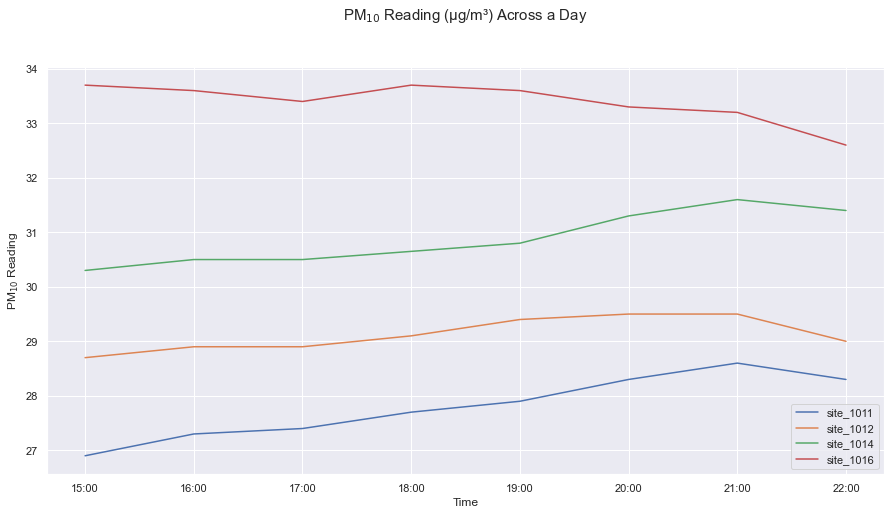

In [107]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(15, 7.5))

ax.plot(site1011['local_time'], site1011['value'], label = 'site_1011')
ax.plot(site1012['local_time'], site1012['value'], label = 'site_1012')
ax.plot(site1014['local_time'], site1014['value'], label = 'site_1014')
ax.plot(site1016['local_time'], site1016['value'], label = 'site_1016')

ax.set_xlabel("Time")
ax.set_ylabel("PM$_{10}$ Reading")
ax.set_title("PM$_{10}$ Reading (µg/m\u00b3) Across a Day", y=1.1, fontsize=15)

custom_tick_labels = ['15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00']
ax.set_xticklabels(custom_tick_labels)

plt.legend()
plt.show()

## Microclimate sensor locations 

In [1]:
#Dataset name
sensor_location_dataset = 'microclimate-sensor-locations'
number_of_records = 20

filters = f'records?limit={number_of_records}&offset=0&timezone=UTC'

sensor_location_url = f'{base_url_v2_1}{sensor_location_dataset}/{filters}'
sensor_location_url

NameError: name 'base_url_v2_1' is not defined

In [130]:
result = requests.get(sensor_location_url)
result_json = result.json()
result_json['total_count']

In [118]:
results = result_json['results']

In [121]:
location_dataset = pd.json_normalize(results)
location_dataset

,site_id,gatewayhub_id,site_status,last_data_local,start_reading,end_reading,latitude,longitude,location.lon,location.lat
0,1016,arc1049,C,2023-08-29 19:00:01,2021-09-17,None,-37.812778,144.960556,144.960556,-37.812778
1,1002,arc1046,R,None,2019-11-15,2021-06-13,-37.800524,144.964122,144.964122,-37.800524
2,1003,arc1047,R,None,2019-11-15,2021-06-13,-37.802300,144.960923,144.960923,-37.802300
3,1015,arc1046,R,None,2021-09-17,None,-37.810278,144.972500,144.972500,-37.810278
4,1009,arc1050,C,2023-08-29 19:00:01,2021-06-14,None,-37.816868,144.965705,144.965705,-37.816868
5,1007,arc1113,C,2022-07-20 15:00:01,2021-05-20,None,-37.822460,144.951835,144.951835,-37.822460
6,1012,arc1048,C,2023-08-29 19:00:01,2021-09-17,None,-37.813333,144.970000,144.970000,-37.813333
7,1014,arc1045,C,2023-08-29 19:00:01,2021-09-17,None,-37.817500,144.967222,144.967222,-37.817500
8,1004,arc1048,R,None,2019-11-15,2021-06-13,-37.800575,144.964635,144.964635,-37.800575
9,1006,arc1112,R,None,2021-05-20,2021-06-28,-37.822486,144.952065,144.952065,-37.822486


In [127]:
# Merging sensor location data with reading data.
pm10 = pd.merge(pm10SiteCount, location_dataset, on='site_id')
pm10 = pm10.drop(['gatewayhub_id', 'end_reading', 'last_data_local', 'location.lon', 'location.lat'], axis=1)
pm10 = pm10.convert_dtypes()

In [128]:
# Drop retired sensors, remaining sensors running since at least September 2021.
pm10 = pm10[pm10['site_status'] != 'R']
pm10

,site_id,value_count,value_mean,site_status,start_reading,latitude,longitude
0,1009,9,18.077778,C,2021-06-14,-37.816868,144.965705
1,1011,23,205.54,C,2021-07-07,-37.822222,144.952222
2,1012,17,18.361176,C,2021-09-17,-37.813333,144.97
3,1014,27,99.592963,C,2021-09-17,-37.8175,144.967222
4,1016,24,145.839167,C,2021-09-17,-37.812778,144.960556


## Pedestrian Counting System (counts per hour)

In [4]:
#Dataset name
ped_count_dataset = 'pedestrian-counting-system-monthly-counts-per-hour'
number_of_records = 100

filters = f'records?limit={number_of_records}&offset=0&timezone=UTC'

ped_count_url = f'{base_url_v2}{ped_count_dataset}/{filters}'
ped_count_url

'https://data.melbourne.vic.gov.au/api/explore/v2.0/catalog/datasets/pedestrian-counting-system-monthly-counts-per-hour/records?limit=100&offset=0&timezone=UTC'

In [5]:
result = requests.get(ped_count_url)
result_json = result.json()
result_json['total_count']

274134

In [6]:
records = result_json['records']
ped_count_df = pd.json_normalize(records)
ped_count_df.drop(columns = ['links'], inplace=True)

In [7]:
column_names = ped_count_df.columns.values.tolist()
column_names = [i.split('.')[-1] for i in column_names]
ped_count_df.columns = column_names

In [15]:
df = extract_dataframe(ped_count_dataset)

In [16]:
df

,id,timestamp,size,timestamp,locationid,direction_1,direction_2,total_of_directions
0,1b9f17e4d8f248cc638b402e8c330e191704de97,2023-09-01T15:30:47.224Z,41,2023-08-31T17:00:00+00:00,1,5,14,19
1,5160671b79b75bff6a5e06940ec14139716ff0da,2023-09-01T15:30:47.224Z,40,2023-08-31T19:00:00+00:00,1,9,6,15
2,00e10e2544f95e1a593771a459b75dffa54592f4,2023-09-01T15:30:47.224Z,45,2023-08-31T23:00:00+00:00,1,322,384,706
3,d2257ba58d5fb0ad931aa588e1bbb54f41f782ed,2023-09-01T15:30:47.224Z,46,2023-09-01T00:00:00+00:00,1,597,515,1112
4,e8f2d8a35a7e5fd53649898cc45494762b2d7034,2023-09-01T15:30:47.224Z,46,2023-09-01T01:00:00+00:00,1,813,652,1465
...,...,...,...,...,...,...,...,...
95,81c8830b2f813d10e0041f0bab8effb6f66599dd,2023-07-27T14:16:02.972Z,40,2023-07-26T17:00:00+00:00,10,1,1,2
96,b5cdfd8399ba8cf664315c8bec72c4664002a2b9,2023-07-27T14:16:02.972Z,41,2023-07-26T19:00:00+00:00,10,6,6,12
97,c0472166d7eed0141c9f22ece2c6aa97372c2d5a,2023-07-27T14:16:02.972Z,45,2023-07-26T23:00:00+00:00,10,83,172,255
98,7ac5c1a5183b6669ff2f4ea1d48662cdc83253ec,2023-07-27T14:16:02.972Z,44,2023-07-27T01:00:00+00:00,10,70,55,125


In [17]:
# Drop columns not being used
pedest_count = df.drop(['id', 'timestamp', 'size', 'direction_1', 'direction_2'], axis=1)

pedest_count = pedest_count.rename(columns={'locationid': 'sensor_id', 'total_of_directions': 'hourly_counts'})

# Convert to correct data types
pedest_count[[ 'sensor_id', 'hourly_counts']] = pedest_count[['sensor_id', 'hourly_counts']].astype(int)
pedest_count = pedest_count.convert_dtypes()

pedest_count.dtypes

sensor_id        Int32
hourly_counts    Int32
dtype: object

In [18]:
groupbyfields = ['sensor_id']
aggregatebyfields = ["mean"]

# Create new DataFrame with mean values for each site.
pedest_mean = pd.DataFrame(pedest_count.groupby(groupbyfields)['hourly_counts'].agg(aggregatebyfields).astype(int)
                           .add_prefix('hourly_counts_'))
pedest_mean = pedest_mean.reset_index()
pedest_mean

,sensor_id,hourly_counts_mean
0,1,839
1,2,442
2,3,1003
3,4,1290
4,5,943
...,...,...
75,117,216
76,118,28
77,122,70
78,123,45


## Pedestrian Counting Sensor location

In [19]:
#Dataset name
ped_location_dataset = 'pedestrian-counting-system-sensor-locations'
number_of_records = 100

filters = f'records?limit={number_of_records}&offset=0&timezone=UTC'

ped_count_url = f'{base_url_v2}{ped_location_dataset}/{filters}'
ped_count_url

'https://data.melbourne.vic.gov.au/api/explore/v2.0/catalog/datasets/pedestrian-counting-system-sensor-locations/records?limit=100&offset=0&timezone=UTC'

In [20]:
result = requests.get(ped_count_url)
result_json = result.json()
result_json['total_count']

113

In [22]:
pedest_loc = extract_dataframe(ped_location_dataset)

In [23]:
pedest_loc

,id,timestamp,size,location_id,sensor_description,sensor_name,installation_date,note,location_type,status,direction_1,direction_2,latitude,longitude,lon,lat
0,97d6ad89c7bad598e920a8ac4f8bf7356d33f596,2023-08-21T15:20:00.504Z,169,2,Bourke Street Mall (South),Bou283_T,2009-03-30,None,Outdoor,A,East,West,-37.813807,144.965167,144.965167,-37.813807
1,37dd097972c7dc3e9f94f0d151490ca835463d36,2023-08-21T15:20:00.504Z,159,4,Town Hall (West),Swa123_T,2009-03-23,None,Outdoor,A,North,South,-37.814880,144.966088,144.966088,-37.814880
2,8de28584efb0abf0e79c71ec97560108e588a40d,2023-08-21T15:20:00.504Z,200,6,Flinders Street Station Underpass,FliS_T,2009-03-25,Upgraded on 8/09/21,Outdoor,A,North,South,-37.819117,144.965583,144.965583,-37.819117
3,5f1f33b5b8bf8deb18ca385acfa5a2549b367454,2023-08-21T15:20:00.504Z,153,8,Webb Bridge,WebBN_T,2009-03-24,None,Outdoor,A,North,South,-37.822935,144.947175,144.947175,-37.822935
4,392d2c94a67571f2b2a9e2f06ad4cdc19d4e3d77,2023-08-21T15:20:00.504Z,158,10,Victoria Point,BouHbr_T,2009-04-23,None,Outdoor,A,East,West,-37.818765,144.947105,144.947105,-37.818765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,f9bd8f49d8f4b8c7402c65b0f37880b663d88983,2023-08-21T15:20:00.504Z,172,107,Flagstaff station (East),280Will_T,2022-10-08,None,Outdoor,A,North,South,-37.812463,144.956902,144.956902,-37.812463
9,2669f2f34caa3199bf01c86bdde4754f93f8a660,2023-08-21T15:20:00.504Z,177,109,La Trobe St- William St (South),LatWill_T,2022-10-08,None,Outdoor,A,East,West,-37.811937,144.956211,144.956211,-37.811937
10,08a8c48cfa8363545c520c10d55f14ed13c5fd11,2023-08-21T15:20:00.504Z,162,110,Birrarung Marr East Entry,BirBlix_T,2021-12-07,None,Outdoor Blix,A,None,None,-37.821029,144.975902,144.975902,-37.821029
11,6c31d0c8fdd354d88f9fe79ff75a92cadc939cf9,2023-08-21T15:20:00.504Z,155,120,Harbour Esplanade,HarbBlix_T,2021-03-25,None,Outdoor Blix,A,None,None,-37.814426,144.944366,144.944366,-37.814426


In [24]:
# Drop columns not likely to be used
pedest_loc = pedest_loc.drop(['id','timestamp','size', 'note', 'location_type', 'sensor_description', 'direction_1', 'direction_2', 'latitude', 'longitude'], axis=1)

pedest_loc = pedest_loc.rename(columns={'location_id': 'sensor_id'})

# Convert to correct data types
pedest_loc[[ 'sensor_id']] = pedest_loc[['sensor_id']].astype(int)
#pedest_loc[['latitude', 'longitude']] = pedest_loc[['latitude', 'longitude']].astype(float)
pedest_loc['installation_date'] = pd.to_datetime(pedest_loc['installation_date'])
pedest_loc = pedest_loc.convert_dtypes()

pedest_loc.dtypes

sensor_id                     Int32
sensor_name                  string
installation_date    datetime64[ns]
status                       string
lon                         Float64
lat                         Float64
dtype: object

In [25]:
# Merging sensor location data with counting data.
pedest = pd.merge(pedest_mean, pedest_loc, on='sensor_id')
pedest

,sensor_id,hourly_counts_mean,sensor_name,installation_date,status,lon,lat
0,1,839,Bou292_T,2009-03-24,A,144.965153,-37.813494
1,2,442,Bou283_T,2009-03-30,A,144.965167,-37.813807
2,3,1003,Swa295_T,2009-03-25,A,144.964295,-37.811015
3,4,1290,Swa123_T,2009-03-23,A,144.966088,-37.81488
4,5,943,PriNW_T,2009-03-26,A,144.967877,-37.818742
...,...,...,...,...,...,...,...
75,117,216,Fli114F_T,2022-12-06,A,144.970909,-37.816293
76,118,28,Fli114C_T,2022-12-06,A,144.970905,-37.816328
77,122,70,FedCycle_T,2022-08-23,A,144.971694,-37.818629
78,123,45,BirBridge_T,2023-06-02,A,144.973297,-37.817537


In [26]:
import folium
from folium.plugins import MarkerCluster
def map_visualization(data):
    locations = []
    for i in range(len(data)):
        row =data.iloc[i]
        location = [(row.lat,row.lon)]*int(row.hourly_counts_mean)
        locations += location
      
    marker_cluster  = MarkerCluster(
      locations=locations,
      overlay=True,
      control=True,
      )
    m = folium.Map(location=[-37.8167, 144.967], zoom_start=15)
    marker_cluster.add_to(m)

    folium.LayerControl().add_to(m)
    
    m
    return m
map_visualization(pedest)

## Butterfly biodiversity survey and insect data

In [11]:
# Base url for v2 api
base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.0/catalog/datasets/'

# Dataset name
dataset = 'butterfly-biodiversity-survey-2017' # enter the dataset indentifier here

# A filter at the end of the url
number_of_records = 100
filters = f'records?limit={number_of_records}&offset=0&timezone=UTC'

In [27]:
bflydata = extract_dataframe(dataset)

In [28]:
bflydata.drop(bflydata.iloc[:, 0:3], inplace=True, axis=1)
bflydata

,site,sloc,walk,date,time,vegwalktime,vegspecies,vegfamily,lat,lon,...,brow,csem,aand,jvil,paur,ogyr,gmac,datetime,lon,lat
0,Womens Peace Gardens,2,1,2017-02-26,0001-01-01T11:42:00+00:00,1.3128,Schinus molle,Anacardiaceae,-37.7912,144.9244,...,0,0,0,0,0,0,0,2017-02-26T11:42:00+00:00,144.9244,-37.7912
1,Argyle Square,1,1,2017-11-02,0001-01-01T10:30:00+00:00,0.3051,Rosmarinus officinalis,Lamiaceae,-37.8023,144.9665,...,0,0,0,0,0,0,0,2017-02-11T10:30:00+00:00,144.9665,-37.8023
2,Argyle Square,2,1,2017-12-01,0001-01-01T10:35:00+00:00,0.3620,Euphorbia sp.,Euphorbiaceae,-37.8026,144.9665,...,0,0,0,0,0,0,0,2017-01-12T10:35:00+00:00,144.9665,-37.8026
3,Westgate Park,4,1,2017-03-03,0001-01-01T11:44:00+00:00,3.1585,Melaleuca lanceolata,Myrtaceae,-37.8316,144.9089,...,0,0,0,0,0,0,0,2017-03-03T11:44:00+00:00,144.9089,-37.8316
4,Argyle Square,1,3,2017-01-15,0001-01-01T12:33:00+00:00,0.4432,Mentha sp.,Lamiaceae,-37.8027,144.9662,...,0,0,0,0,0,0,0,2017-01-15T12:33:00+00:00,144.9662,-37.8027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,Fitzroy-Treasury Gardens,3,2,2017-06-02,0001-01-01T17:44:00+00:00,0.5132,Tagetes sp.,Asteraceae,-37.8136,144.9819,...,0,0,0,0,0,0,0,2017-02-06T17:44:00+00:00,144.9819,-37.8136
52,Westgate Park,4,2,2017-02-02,0001-01-01T13:57:00+00:00,2.1947,Myoporum parvifolium,Scrophulariaceae,-37.8311,144.9092,...,0,0,0,0,0,0,0,2017-02-02T13:57:00+00:00,144.9092,-37.8311
53,Westgate Park,5,3,2017-06-03,0001-01-01T15:43:00+00:00,4.2408,Cassinia arcuata,Asteraceae,-37.8299,144.9106,...,0,0,0,0,0,0,0,2017-03-06T15:43:00+00:00,144.9106,-37.8299
54,Westgate Park,4,1,2017-02-02,0001-01-01T11:05:00+00:00,1.5948,Xerochrysum viscosum,Asteraceae,-37.8316,144.9093,...,0,0,0,0,0,0,0,2017-02-02T11:05:00+00:00,144.9093,-37.8316


In [29]:
#Aggregating the butterfly data as count of individual species by monitoring location.
bflyCounts = bflydata.groupby(["site"])["site"].count().reset_index(name="Butterfly Species Count")
bflyCounts.insert(0, 'id', range(1, 1 + len(bflyCounts)))
bflyCounts

,id,site,Butterfly Species Count
0,1,Argyle Square,256
1,2,Canning/Neill St Reserve,40
2,3,Carlton Gardens South,592
3,4,Fitzroy-Treasury Gardens,572
4,5,Gardiner Reserve,28
5,6,Garrard Street Reserve,44
6,7,Lincoln Square,124
7,8,Murchinson Square,52
8,9,Pleasance Gardens,56
9,10,Princes Park,224


In [18]:
insectdata = extract_dataframe("insect-records-in-the-city-of-melbourne-from-little-things-that-run-the-city")

In [30]:
insectdata.drop(insectdata.iloc[:, 0:3], inplace=True, axis=1)
insectdata

,taxa,kingdom,phylum,class,order,family,genus,species,identification_notes,location,sighting_date
0,Insect,ANIMALIA,ARTHROPODA,INSECTA,COLEOPTERA,LATRIIDAE,Cortinicara,None,Cortinicara sp.1,Royal Park,None
1,Insect,ANIMALIA,ARTHROPODA,INSECTA,COLEOPTERA,LATRIIDAE,Cortinicara,None,Cortinicara sp.1,Westgate Park,None
2,Insect,ANIMALIA,ARTHROPODA,INSECTA,HEMIPTERA,PSYLLIDAE,Creiis,None,Creiis sp. 1,Royal Park,None
3,Insect,ANIMALIA,ARTHROPODA,INSECTA,HEMIPTERA,MIRIDAE,Creontiades,dilutus,None,Lincoln Square,None
4,Insect,ANIMALIA,ARTHROPODA,INSECTA,COLEOPTERA,COCCINELLIDAE,Cryptolaemus,montrouzeri,None,State Library of Victoria,None
...,...,...,...,...,...,...,...,...,...,...,...
90,Insect,ANIMALIA,ARTHROPODA,INSECTA,COLEOPTERA,LATRIIDAE,Corticaria,None,Corticaria sp.1,Princes Park,None
91,Insect,ANIMALIA,ARTHROPODA,INSECTA,COLEOPTERA,LATRIIDAE,Cortinicara,None,Cortinicara sp.1,Canning/Neil Street Reserve,None
92,Insect,ANIMALIA,ARTHROPODA,INSECTA,COLEOPTERA,LATRIIDAE,Cortinicara,None,Cortinicara sp.1,Murchinson Square,None
93,Insect,ANIMALIA,ARTHROPODA,INSECTA,COLEOPTERA,LATRIIDAE,Cortinicara,None,Cortinicara sp.1,Pleasance Gardens,None


In [32]:
#Aggregating the insect data as count of individual species by monitoring location.
insectCounts = insectdata.groupby(["location"])["location"].count().reset_index(name="Miscellaneous Insect Count")

#Creating id index
insectCounts.insert(0, 'id', range(1, 1 + len(insectCounts)))

# Renaming the monitoring location column to something more intuitive.
insectCounts = insectCounts.rename({'location': 'Location'}, axis=1) 

insectCounts

,id,Location,Miscellaneous Insect Count
0,1,Argyle Square,43
1,2,Canning/Neil Street Reserve,14
2,3,Carlton Gardens South,97
3,4,Fitzroy-Treasury Gardens,150
4,5,Gardiner Reserve,24
5,6,Garrard Street Reserve,26
6,7,Lincoln Square,37
7,8,Murchinson Square,14
8,9,Pleasance Gardens,42
9,10,Princes Park,177


In [35]:
#Creating point data shapefile to align with the monitoring locations. Coordinates taken from external mapping software (QGIS).

insectCoords = pd.DataFrame({'longitude': [2496990.9139893204, 2497716.4106032336, 2497468.0019974816,2497904.2864259947,2495048.0358508285,2494903.373709257,2496730.7911691167,2497631.1602672394,2495215.229639408,2496593.58352767,
                                 2495657.343150738,2496862.1697277585,2496501.887571214,2491904.086409784,2493312.0341030643], 
                   
                   'latitude': [2410917.9145240453, 2411981.946331717, 2410514.362637444,2409637.309870564,2411319.224455721,2413521.833072339,2410956.1398554766,2411196.477423501,2411624.2424233076,2412883.3243095265,
                                2412807.994624026,2410110.0260665533,2411092.4507149556,2407712.4794691135,2412201.7700121445]})

insectCounts['geometry'] = gpd.points_from_xy(insectCoords.longitude, insectCoords.latitude, crs="EPSG:3111")

insectCounts

,id,Location,Miscellaneous Insect Count,geometry
0,1,Argyle Square,43,POINT (2496990.914 2410917.915)
1,2,Canning/Neil Street Reserve,14,POINT (2497716.411 2411981.946)
2,3,Carlton Gardens South,97,POINT (2497468.002 2410514.363)
3,4,Fitzroy-Treasury Gardens,150,POINT (2497904.286 2409637.310)
4,5,Gardiner Reserve,24,POINT (2495048.036 2411319.224)
5,6,Garrard Street Reserve,26,POINT (2494903.374 2413521.833)
6,7,Lincoln Square,37,POINT (2496730.791 2410956.140)
7,8,Murchinson Square,14,POINT (2497631.160 2411196.477)
8,9,Pleasance Gardens,42,POINT (2495215.230 2411624.242)
9,10,Princes Park,177,POINT (2496593.584 2412883.324)


In [36]:
#Adding butterfly data to insect data.
insectCounts = pd.merge(left=insectCounts, right=bflyCounts, how='left', left_on='id', right_on='id')
insectCounts = insectCounts.drop(['site'], axis=1)

#Summing counts of misc. insects and butterflies.
insectCounts['Total Insect Count'] = insectCounts["Miscellaneous Insect Count"] + insectCounts["Butterfly Species Count"]

#Converting dataframe to geopandas format.
insectCounts = gpd.GeoDataFrame(insectCounts, geometry='geometry')

insectCounts

,id,Location,Miscellaneous Insect Count,geometry,Butterfly Species Count,Total Insect Count
0,1,Argyle Square,43,POINT (2496990.914 2410917.915),256,299
1,2,Canning/Neil Street Reserve,14,POINT (2497716.411 2411981.946),40,54
2,3,Carlton Gardens South,97,POINT (2497468.002 2410514.363),592,689
3,4,Fitzroy-Treasury Gardens,150,POINT (2497904.286 2409637.310),572,722
4,5,Gardiner Reserve,24,POINT (2495048.036 2411319.224),28,52
5,6,Garrard Street Reserve,26,POINT (2494903.374 2413521.833),44,70
6,7,Lincoln Square,37,POINT (2496730.791 2410956.140),124,161
7,8,Murchinson Square,14,POINT (2497631.160 2411196.477),52,66
8,9,Pleasance Gardens,42,POINT (2495215.230 2411624.242),56,98
9,10,Princes Park,177,POINT (2496593.584 2412883.324),224,401


## Canopy

In [127]:
canopies = extract_dataframe("tree-canopies-2019")

In [128]:
canopies.drop(canopies.iloc[:, 0:3], inplace=True, axis=1)
canopies

,lon,lat,type,coordinates,type
0,144.956620,-37.803398,Feature,"[[[144.9566248325, -37.8034144011], [144.95662...",Polygon
1,144.955416,-37.803382,Feature,"[[[144.955418644, -37.803393464900005], [144.9...",Polygon
2,144.946449,-37.803232,Feature,"[[[144.9464588306, -37.8032375595], [144.94645...",Polygon
3,144.962095,-37.803477,Feature,"[[[144.9620886681, -37.8034910604], [144.96209...",Polygon
4,144.936249,-37.803047,Feature,"[[[144.9362505352, -37.8030523398], [144.93625...",Polygon
...,...,...,...,...,...
95,144.973369,-37.825027,Feature,"[[[144.973365932, -37.825025559], [144.9733659...",Polygon
96,144.928138,-37.824240,Feature,"[[[144.9281366075, -37.8242405779], [144.92813...",Polygon
97,144.945012,-37.824533,Feature,"[[[144.94501369, -37.8245341104], [144.9450137...",Polygon
98,144.928501,-37.824244,Feature,"[[[144.9284972031, -37.82424467], [144.9284986...",Polygon


In [129]:
def row_to_geometry(row):
    return Polygon(row['coordinates'][0])



canopies['geometry'] = canopies.apply(row_to_geometry, axis=1)
canopies = gpd.GeoDataFrame(canopies, geometry='geometry')

In [130]:
canopies

,lon,lat,type,coordinates,type,geometry
0,144.956620,-37.803398,Feature,"[[[144.9566248325, -37.8034144011], [144.95662...",Polygon,"POLYGON ((144.95662 -37.80341, 144.95662 -37.8..."
1,144.955416,-37.803382,Feature,"[[[144.955418644, -37.803393464900005], [144.9...",Polygon,"POLYGON ((144.95542 -37.80339, 144.95542 -37.8..."
2,144.946449,-37.803232,Feature,"[[[144.9464588306, -37.8032375595], [144.94645...",Polygon,"POLYGON ((144.94646 -37.80324, 144.94646 -37.8..."
3,144.962095,-37.803477,Feature,"[[[144.9620886681, -37.8034910604], [144.96209...",Polygon,"POLYGON ((144.96209 -37.80349, 144.96209 -37.8..."
4,144.936249,-37.803047,Feature,"[[[144.9362505352, -37.8030523398], [144.93625...",Polygon,"POLYGON ((144.93625 -37.80305, 144.93625 -37.8..."
...,...,...,...,...,...,...
95,144.973369,-37.825027,Feature,"[[[144.973365932, -37.825025559], [144.9733659...",Polygon,"POLYGON ((144.97337 -37.82503, 144.97337 -37.8..."
96,144.928138,-37.824240,Feature,"[[[144.9281366075, -37.8242405779], [144.92813...",Polygon,"POLYGON ((144.92814 -37.82424, 144.92814 -37.8..."
97,144.945012,-37.824533,Feature,"[[[144.94501369, -37.8245341104], [144.9450137...",Polygon,"POLYGON ((144.94501 -37.82453, 144.94501 -37.8..."
98,144.928501,-37.824244,Feature,"[[[144.9284972031, -37.82424467], [144.9284986...",Polygon,"POLYGON ((144.92850 -37.82424, 144.92850 -37.8..."


In [131]:
canopies = canopies.set_crs("EPSG:4326")
print(canopies.crs)

EPSG:4326


In [132]:
#Creating circles (buffers) of 50m and 100m radius around the insect monitoring locations. These will be combined with the tree canopy data to determine relationship between canopy and insect variety.

insectBuffer50 = insectCounts.buffer(50)
insectBuffer100 = insectCounts.buffer(100)
insectBuffer200 = insectCounts.buffer(200)

insectBuffer50 = gpd.GeoDataFrame(geometry=gpd.GeoSeries(insectBuffer50))
insectBuffer100 = gpd.GeoDataFrame(geometry=gpd.GeoSeries(insectBuffer100))
insectBuffer200 = gpd.GeoDataFrame(geometry=gpd.GeoSeries(insectBuffer200))

insectBuffer50.insert(0, 'id', range(1, 1 + len(insectBuffer50)))
insectBuffer100.insert(0, 'id', range(1, 1 + len(insectBuffer100)))
insectBuffer200.insert(0, 'id', range(1, 1 + len(insectBuffer200)))

#Creating areas of canopy around insect monitoring locations. Note may need to install rtree to enable the overlay operation.
insectCanopies50 = canopies.to_crs(3577).overlay(insectBuffer50.to_crs(3577), how='intersection')
insectCanopies100 = canopies.to_crs(3577).overlay(insectBuffer100.to_crs(3577), how='intersection')
insectCanopies200 = canopies.to_crs(3577).overlay(insectBuffer200.to_crs(3577), how='intersection')

print(insectCanopies50)


C:\Users\playroommountains\AppData\Local\Temp\ipykernel_6904\4059564646.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  insectBuffer50 = insectCounts.buffer(50)
C:\Users\playroommountains\AppData\Local\Temp\ipykernel_6904\4059564646.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  insectBuffer100 = insectCounts.buffer(100)
C:\Users\playroommountains\AppData\Local\Temp\ipykernel_6904\4059564646.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  insectBuffer200 = insectCounts.buffer(200)


Empty GeoDataFrame
Columns: [lon, lat, type, type, coordinates, type, type, id, geometry]
Index: []


In [133]:
insectCounts_projected = insectCounts.to_crs(3577)

insectBuffer50 = insectCounts_projected.buffer(50)
insectBuffer100 = insectCounts_projected.buffer(100)
insectBuffer200 = insectCounts_projected.buffer(200)

insectBuffer50 = gpd.GeoDataFrame(geometry=gpd.GeoSeries(insectBuffer50))
insectBuffer100 = gpd.GeoDataFrame(geometry=gpd.GeoSeries(insectBuffer100))
insectBuffer200 = gpd.GeoDataFrame(geometry=gpd.GeoSeries(insectBuffer200))

insectBuffer50.insert(0, 'id', range(1, 1 + len(insectBuffer50)))
insectBuffer100.insert(0, 'id', range(1, 1 + len(insectBuffer100)))
insectBuffer200.insert(0, 'id', range(1, 1 + len(insectBuffer200)))

# Since both canopies and insectBuffers are now in the same CRS (EPSG:3577), you can proceed with the overlay operation
insectCanopies50 = canopies.to_crs(3577).overlay(insectBuffer50, how='intersection')
insectCanopies100 = canopies.to_crs(3577).overlay(insectBuffer100, how='intersection')
insectCanopies200 = canopies.to_crs(3577).overlay(insectBuffer200, how='intersection')

print(insectCanopies50)


C:\Users\playroommountains\anaconda3\lib\site-packages\geopandas\array.py:968: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 0]),  # minx
C:\Users\playroommountains\anaconda3\lib\site-packages\geopandas\array.py:969: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 1]),  # miny
C:\Users\playroommountains\anaconda3\lib\site-packages\geopandas\array.py:970: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 2]),  # maxx
C:\Users\playroommountains\anaconda3\lib\site-packages\geopandas\array.py:971: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 3]),  # maxy


Empty GeoDataFrame
Columns: [lon, lat, type, type, coordinates, type, type, id, geometry]
Index: []


In [134]:
#Calculating the area of canopy cover and adding it as a variable.

insectCanopies50['area'] = insectCanopies50['geometry'].area
insectCanopies100['area'] = insectCanopies100['geometry'].area
insectCanopies200['area'] = insectCanopies200['geometry'].area

In [135]:
#Summing canopy area by insect study location.
insectCanopies50 = insectCanopies50.groupby(["id_2"], as_index=False)["area"].sum()
insectCanopies100 = insectCanopies100.groupby(["id_2"], as_index=False)["area"].sum()
insectCanopies200 = insectCanopies200.groupby(["id_2"], as_index=False)["area"].sum()

KeyError: 'id_2'